In [7]:
import pandas as pd

# On charge le dataset une bonne fois pour toutes pour tout le notebook
df = pd.read_csv('dataset.csv') 

# Si le fichier est dans le dossier ressources, utilisez :
# df = pd.read_csv('ressources/dataset.csv')

print("Dataset chargé avec succès !")
print(f"Nombre de lignes : {len(df)}")

Dataset chargé avec succès !
Nombre de lignes : 2423


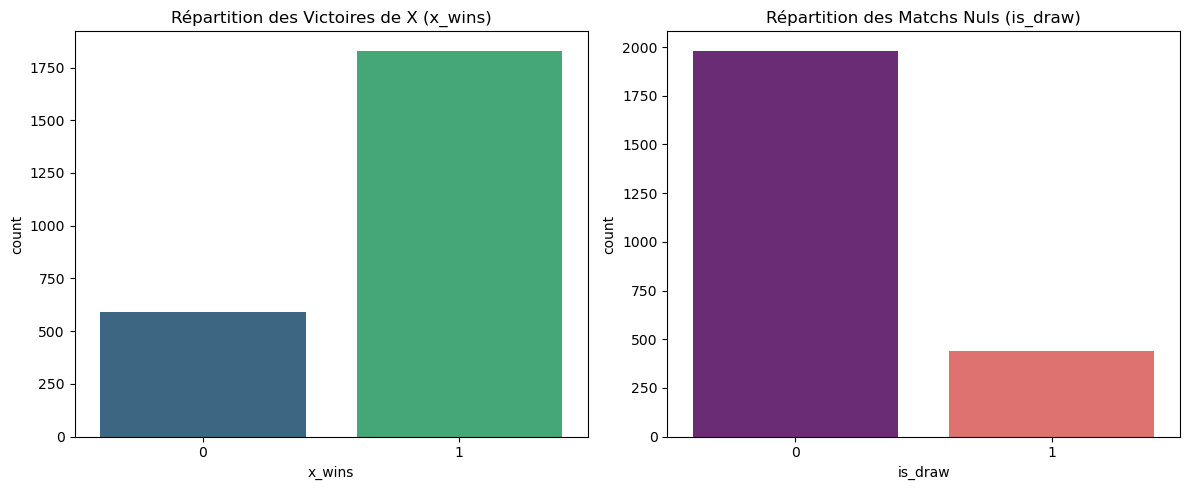

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Distribution de x_wins - On ajoute hue='x_wins' et legend=False
plt.subplot(1, 2, 1)
sns.countplot(x='x_wins', data=df, hue='x_wins', palette='viridis', legend=False)
plt.title('Répartition des Victoires de X (x_wins)')

# Distribution de is_draw - On ajoute hue='is_draw' et legend=False
plt.subplot(1, 2, 2)
sns.countplot(x='is_draw', data=df, hue='is_draw', palette='magma', legend=False)
plt.title('Répartition des Matchs Nuls (is_draw)')

plt.tight_layout()
plt.show()

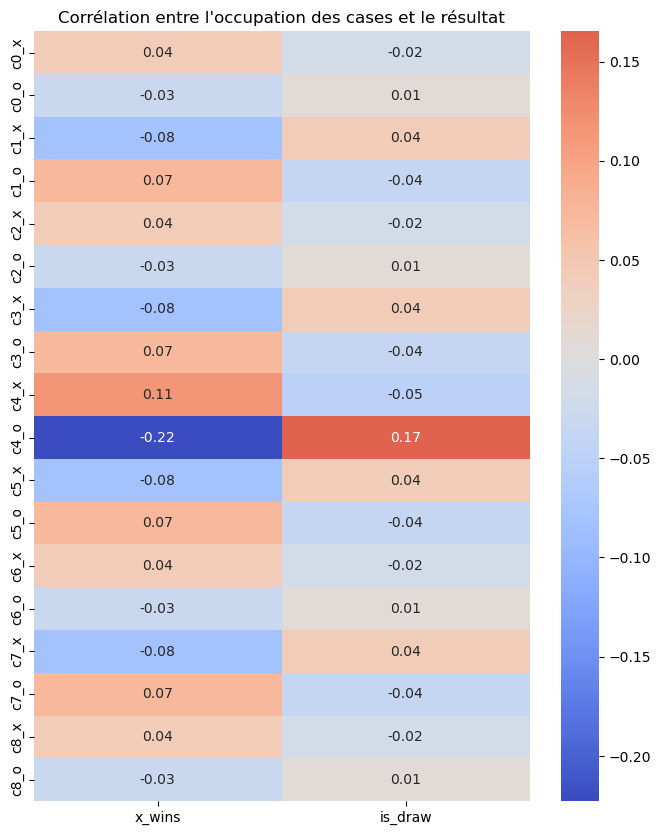

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# On calcule la corrélation uniquement pour les cibles qui nous intéressent
# On prend les 18 premières colonnes (les cases) et les 2 dernières (les cibles)
correlations = df.corr()[['x_wins', 'is_draw']].iloc[:18]

plt.figure(figsize=(8, 10))
sns.heatmap(correlations, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Corrélation entre l'occupation des cases et le résultat")
plt.show()

# Étape 1 : Analyse Exploratoire des Données (EDA)

Cette étape vise à comprendre la structure du dataset de 2423 configurations avant l'entraînement des modèles.

## 1. Distribution des cibles (Équilibre du dataset)

Nous avons analysé la répartition des classes pour nos deux objectifs de prédiction : `x_wins` (Victoire de X) et `is_draw` (Match nul).



**Analyse :**
* **x_wins :** Le dataset est relativement déséquilibré en faveur des victoires de X. La classe 1 (victoire) est beaucoup plus représentée que la classe 0. Cela explique pourquoi le modèle de baseline obtient naturellement une meilleure précision sur les victoires.
* **is_draw :** Le déséquilibre est **critique**. Les matchs nuls ne représentent qu'environ 17% des données. 
* **Conclusion :** Le dataset est **fortement déséquilibré**. L'utilisation de l'Accuracy comme métrique unique serait une erreur, car un modèle prédisant "jamais de nul" afficherait une bonne accuracy tout en étant inutile. Nous privilégions donc le **F1-Score**.

## 2. Analyse des positions gagnantes pour X

Nous avons cherché à identifier quelle case est la plus souvent occupée par le joueur X dans les configurations où il remporte la partie.

**Analyse technique :**
En filtrant le dataset sur `x_wins == 1` et en calculant la moyenne d'occupation des colonnes `c0_x` à `c8_x`, nous observons que :
* La **case centrale (c4)** est la plus fréquemment occupée dans les victoires de X.
* Cela confirme la stratégie classique du Morpion : le centre est la position offrant le plus grand nombre de combinaisons gagnantes possibles (diagonales, ligne médiane, colonne médiane).

## 3. Corrélation entre les features et les cibles

La Heatmap ci-dessous montre la force du lien mathématique entre l'occupation d'une case et le résultat final.



**Interprétations clés :**
* **Cible `x_wins` :** On observe une corrélation positive forte pour les cases stratégiques (centre et coins) lorsqu'elles sont occupées par X (`c_x`), et une corrélation négative forte lorsqu'elles sont occupées par O (`c_o`).
* **Cible `is_draw` :** Les coefficients de corrélation sont très proches de zéro pour toutes les cases individuellement. 
* **Conclusion :** Cela prouve qu'un match nul ne dépend pas d'une seule case "magique", mais d'une configuration complexe de tout le plateau. C'est ce qui rend la prédiction des matchs nuls beaucoup plus difficile pour une Régression Logistique (Baseline).

---
*Note : Ces observations ont directement conduit au choix du paramètre `class_weight='balanced'` lors de l'étape de modélisation pour compenser le déséquilibre identifié ici.*